In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [110]:
df = pd.read_csv("iris.csv")

In [111]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [112]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [114]:
df.isnull()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
145,False,False,False,False,False,False
146,False,False,False,False,False,False
147,False,False,False,False,False,False
148,False,False,False,False,False,False


In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [116]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [117]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [118]:
x.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


In [119]:
y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str

In [120]:
y.shape

(150,)

In [121]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [122]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])


print(df['Species'].head())


0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64


In [123]:
y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str

In [124]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [125]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [126]:
df.drop("Id",axis =1 , inplace =True)

before oulier detection

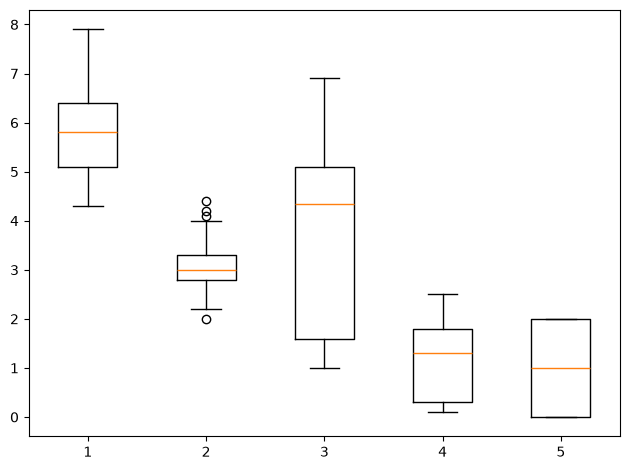

In [127]:
plt.Figure(figsize=(8,10))

plt.boxplot([
    df["SepalLengthCm"],
    df["SepalWidthCm"],
    df["PetalLengthCm"],
    df["PetalWidthCm"],
    df["Species"]
])

plt.tight_layout()
plt.show()

outlier remove using iqr

In [128]:
numeric_df = df.select_dtypes(include=["number"])

q1 = numeric_df.quantile(0.25)
q3  = numeric_df.quantile(0.75)

iqr = q3 -q1
l_b = q1 - 1.5*iqr
u_b  = q3 + 1.5*iqr

outlier_mask = ((numeric_df < l_b) | (numeric_df >u_b)).any(axis=1)
df_clean = df[~outlier_mask]

after outlier removal

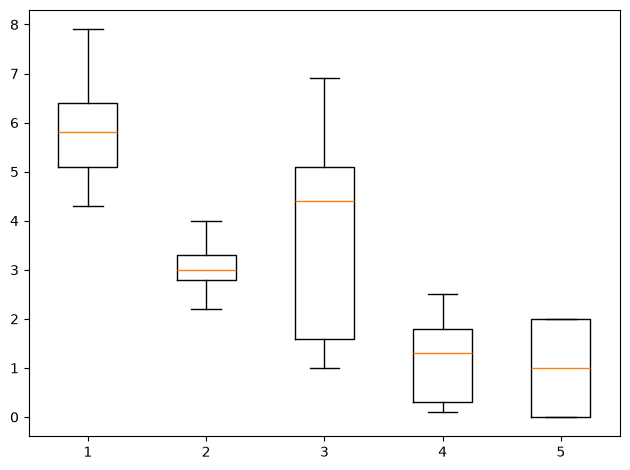

In [129]:
plt.Figure(figsize=(8,10))

plt.boxplot([
    df_clean["SepalLengthCm"],
    df_clean["SepalWidthCm"],
    df_clean["PetalLengthCm"],
    df_clean["PetalWidthCm"],
    df_clean["Species"]
])

plt.tight_layout()
plt.show()

cooreletion matrix

<Axes: >

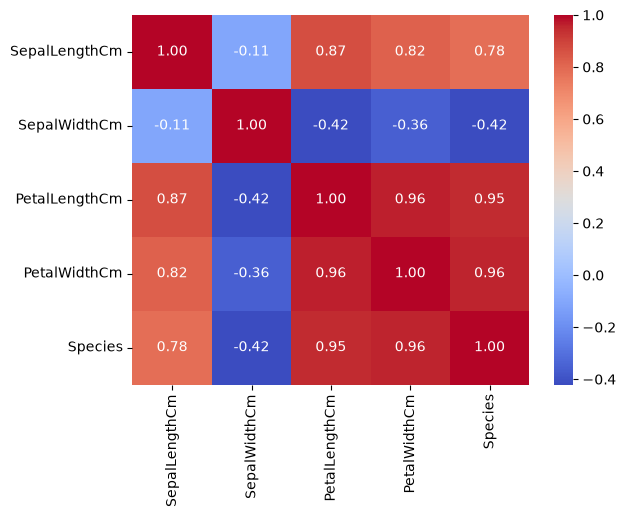

In [130]:
corr_matrix = df.corr(numeric_only= True)

sns.heatmap(
    corr_matrix,
    annot= True,
    fmt = ".2f",

    cmap= "coolwarm"
)


In [131]:
df.corr()["Species"].sort_values(ascending = False)

Species          1.000000
PetalWidthCm     0.956464
PetalLengthCm    0.949043
SepalLengthCm    0.782561
SepalWidthCm    -0.419446
Name: Species, dtype: float64

Linear Regression

In [132]:
x_1 = df[["PetalWidthCm"]]
y_1 = df.iloc[:,-1]

In [133]:
x_1.head()

,PetalWidthCm
0,0.2
1,0.2
2,0.2
3,0.2
4,0.2


In [134]:
y_1.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

In [135]:
y_1.tail()

145    2
146    2
147    2
148    2
149    2
Name: Species, dtype: int64

In [136]:
from sklearn.model_selection import train_test_split
x_1_train ,x_1_test ,y_1_train , y_1_test = train_test_split(x_1,y_1,test_size=0.2,random_state=42)

In [137]:
y_1_train.head()

22    0
15    0
65    1
11    0
42    0
Name: Species, dtype: int64

In [138]:
from sklearn.linear_model import LinearRegression
model_1 =LinearRegression()
model_1.fit(x_1_train,y_1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['PetalWidthCm']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.2246
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [139]:
y_pred = model_1.predict(x_1_test)

In [140]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
y_pred = model_1.predict(x_1_test)
print("coefficient (m):",model_1.coef_[0])
print("intercept (b)" , model_1.intercept_)
print(f"SEM 5 = {model_1.coef_[0]:.4f}* (SEM 2) + {model_1.intercept_:.4f}")
mae = mean_absolute_error(y_1_test,y_pred)
mse = mean_squared_error(y_1_test,y_pred)
rmse = root_mean_squared_error(y_1_test,y_pred)
r2 = r2_score(y_1_test,y_pred)
print("MAE = ",mae)
print("MSE = ",mse)
print("RMSE = ",rmse)
print("r2 = ",r2)

coefficient (m): 1.0285589516418532
intercept (b) -0.22460429364982448
SEM 5 = 1.0286* (SEM 2) + -0.2246
MAE =  0.14409940799788815
MSE =  0.033449504746138815
RMSE =  0.18289205763547747
r2 =  0.9521390234156997


In [141]:
x_2 = df.iloc[:,:-1]
y_2 = df.iloc[:,-1]

In [142]:
x_2_train,x_2_test,y_2_train,y_2_test = train_test_split(x_2,y_2,test_size=0.2,random_state=42)

In [143]:
model_2 = LinearRegression()
model_2.fit(x_2_train,y_2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.11,-0.06, 0.25, 0.55]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.2583
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [144]:
print("coefficient (m):",model_2.coef_)
print("intercept (b)" , model_2.intercept_)

for feature , coef in zip(x_2.columns , model_1.coef_):
    print(f"{feature} :  {coef:.4f}")
print("intercept (b)" , model_2.intercept_)


print(f""" SEM 5 = ({model_2.coef_[0]})* SEM 1)
+({model_2.coef_[1]})* SEM 2)
+({model_2.coef_[2]})* SEM 3)
+({model_2.coef_[3]})* SEM 4)
+({model_2.intercept_:.4f})""")
print(f"SEM 5 = {model_2.coef_[0]:.4f}* (SEM 2) + {model_2.intercept_:.4f}")

y_1_pred = model_2.predict(x_2_test)
mae_1 = mean_absolute_error(y_2_test,y_1_pred)
mse_1 = mean_squared_error(y_2_test,y_1_pred)
rmse_1 = root_mean_squared_error(y_2_test,y_1_pred)
r2_1 = r2_score(y_2_test,y_1_pred)
print("MAE = ",mae_1)
print("MSE = ",mse_1)
print("RMSE = ",rmse_1)
print("r2 = ",r2_1)

coefficient (m): [-0.11368098 -0.06458377  0.25261442  0.54938903]
intercept (b) 0.25825051246344954
SepalLengthCm :  1.0286
intercept (b) 0.25825051246344954
 SEM 5 = (-0.11368097603980228)* SEM 1)
+(-0.06458377395554421)* SEM 2)
+(0.2526144201824223)* SEM 3)
+(0.5493890304328676)* SEM 4)
+(0.2583)
SEM 5 = -0.1137* (SEM 2) + 0.2583
MAE =  0.1466990776263419
MSE =  0.03723364456197505
RMSE =  0.19296021497183052
r2 =  0.9467245149351708


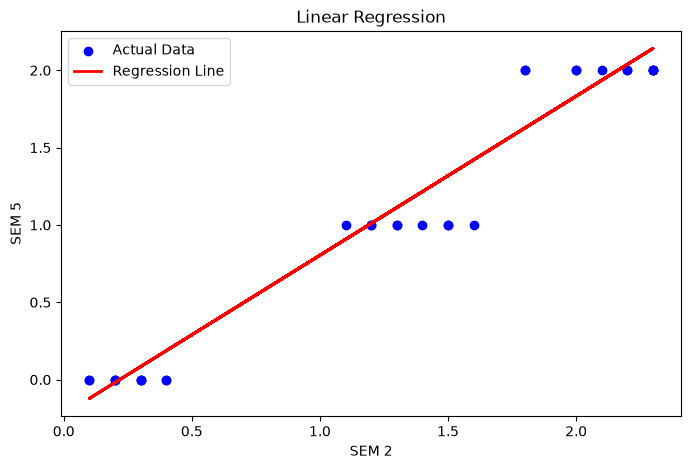

In [145]:
plt.figure(figsize=(8,5))
plt.scatter(x_1_test, y_1_test, color="blue", label="Actual Data")


plt.plot(x_1_test, y_pred, color="red", linewidth=2, label="Regression Line")

plt.title("Linear Regression")
plt.xlabel("SEM 2")
plt.ylabel("SEM 5")
plt.legend()

plt.show()

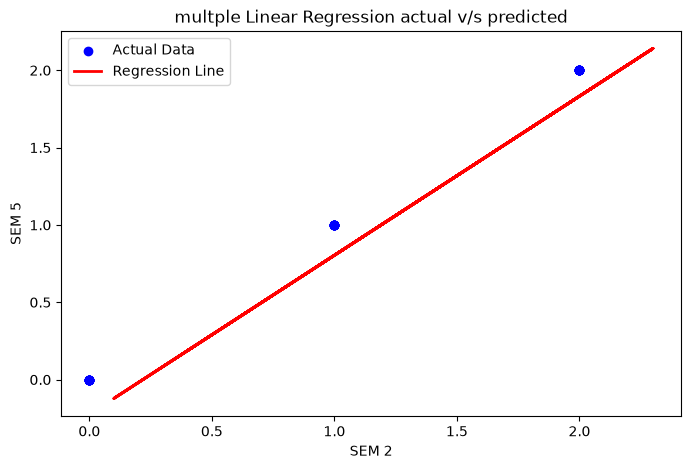

In [149]:
plt.figure(figsize=(8,5))
plt.scatter(y_2_test, y_1_test, color="blue", label="Actual Data")


plt.plot(x_1_test, y_pred, color="red", linewidth=2, label="Regression Line")

plt.title("multple Linear Regression actual v/s predicted")
plt.xlabel("SEM 2")
plt.ylabel("SEM 5")
plt.legend()

plt.show()

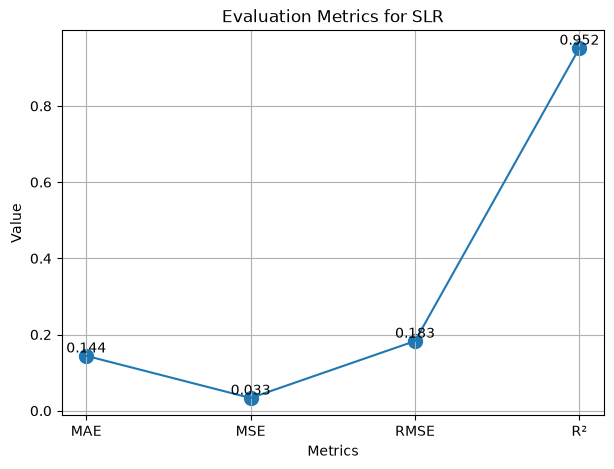

In [147]:


# Evaluation metrics
metrics = ["MAE", "MSE", "RMSE", "R²"]
values = [mae, mse, rmse, r2]

plt.figure(figsize=(7,5))

plt.scatter(metrics, values, s=100)

# Join the points 
plt.plot(metrics, values)

# Display values
for i in range(len(metrics)):
    plt.text(metrics[i], values[i], f"{values[i]:.3f}", ha="center", va="bottom")

plt.title("Evaluation Metrics for SLR")
plt.xlabel("Metrics")
plt.ylabel("Value")

plt.grid(True)
plt.show()

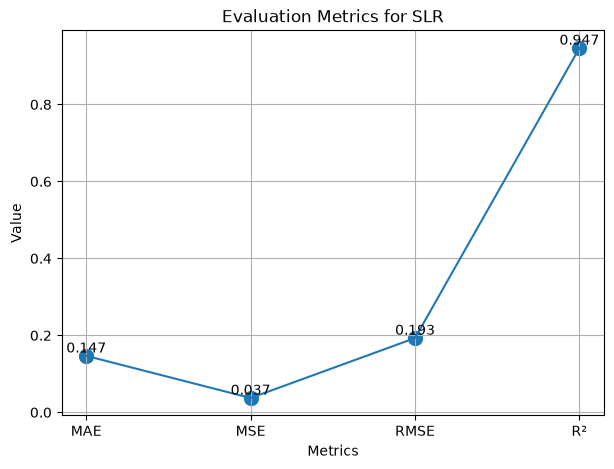

In [148]:


# Evaluation metrics
metrics = ["MAE", "MSE", "RMSE", "R²"]
values = [mae_1, mse_1, rmse_1, r2_1]

plt.figure(figsize=(7,5))

plt.scatter(metrics, values, s=100)

# Join the points 
plt.plot(metrics, values)

# Display values
for i in range(len(metrics)):
    plt.text(metrics[i], values[i], f"{values[i]:.3f}", ha="center", va="bottom")

plt.title("Evaluation Metrics for SLR")
plt.xlabel("Metrics")
plt.ylabel("Value")

plt.grid(True)
plt.show()